<a href="https://colab.research.google.com/github/kinchittrivedi/Kaggle/blob/main/Intermediate_NLP_Bidirectional_Long_Short_Term.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
google_wiki_words_tensorflow2_250_1_path = kagglehub.model_download('google/wiki-words/TensorFlow2/250/1')

print('Data source import complete.')



100%|██████████| 218/218 [00:00<00:00, 505kB/s]


  0%|          | 0.00/8.27M [00:00<?, ?B/s]

  0%|          | 0.00/23.0k [00:00<?, ?B/s]

100%|██████████| 23.0k/23.0k [00:00<00:00, 27.0MB/s]


  0%|          | 0.00/963M [00:00<?, ?B/s]
 36%|███▋      | 3.00M/8.27M [00:00<00:00, 28.7MB/s]

100%|██████████| 8.27M/8.27M [00:00<00:00, 46.2MB/s]


  2%|▏         | 19.0M/963M [00:00<00:09, 104MB/s] 

  4%|▎         | 34.0M/963M [00:00<00:07, 128MB/s]

  5%|▍         | 47.0M/963M [00:00<00:08, 115MB/s]

  6%|▌         | 59.0M/963M [00:00<00:08, 113MB/s]

  7%|▋         | 70.0M/963M [00:00<00:10, 88.8MB/s]

  8%|▊         | 80.0M/963M [00:00<00:10, 92.4MB/s]

  9%|▉         | 91.0M/963M [00:01<00:11, 79.3MB/s]

 11%|█         | 102M/963M [00:01<00:10, 87.7MB/s] 

 12%|█▏        | 115M/963M [00:01<00:09, 97.9MB/s]

 13%|█▎        | 125M/963M [00:01<00:09, 89.1MB/s]

 14%|█▍        | 135M/963M [00:01<00:10, 83.9MB/s]

 15%|█▌        | 147M/963M [00:01<00:09, 92.8MB/s]

 16%|█▋        | 157M/963M [00:01<00:09, 91.1MB/s]

 18%|█▊        | 171M/963M [00:01<00:08, 104MB/s] 

 19%|█▉        | 183M/963M [00:01<00:07, 109MB/s]

 20%|██  

Data source import complete.


# Intermediate NLP: Bidirectional Long Short-Term Memory

Welcome to Module 5! In the previous section **[(Module 4)](https://www.kaggle.com/code/arminnorouzig/intermediate-nlp-long-short-term-memory-lstm)**, we saw how Recurrent Neural Networks (RNNs) and Long Short-Term Memory (LSTM) networks process text sequentially from left to right.

However, human language doesn't always reveal its full meaning sequentially. Often, the linguistic reality is that the meaning of a word relies heavily on words that appear much *later* in a sentence.

Consider the word **"bank"** in these two sentences:
1. "I went to the **bank** to deposit my check."
2. "I sat on the **bank** of the river to watch the boats."

If a standard LSTM reads left-to-right, when it hits the word "bank", it only has the context of "I went to the..." or "I sat on the...". It hasn't seen "check" or "river" yet! To truly understand "bank" at the exact moment it is processed, the network needs context from the *future*. Enter **Bidirectional RNNs**.


## The Mathematics of Bidirectional Networks

A Bidirectional RNN is elegantly simple: it is actually **two** separate RNNs (or LSTMs) operating side-by-side.
* One network reads the sequence strictly forward (left-to-right).
* One network reads the sequence strictly backward (right-to-left).

For any given time step $t$, we calculate two independent hidden states:

**1. The Forward Hidden State ($\overrightarrow{H}_t$)**
This is calculated using the current word and the *previous* forward hidden state.
$$ \overrightarrow{H}_t = \text{LSTM}(X_t, \overrightarrow{H}_{t-1}) $$

**2. The Backward Hidden State ($\overleftarrow{H}_t$)**
This is calculated using the current word and the *next* backward hidden state (because it's reading in reverse).
$$ \overleftarrow{H}_t = \text{LSTM}(X_t, \overleftarrow{H}_{t+1}) $$

**3. The Combined Output State ($Y_t$)**
Finally, we concatenate (glue together) both hidden states to form the final way to show that word.
$$ Y_t = [\overrightarrow{H}_t, \overleftarrow{H}_t] $$

Because $Y_t$ contains both the forward and backward states, the mathematical way to show the word $X_t$ now possesses complete knowledge of the *entire* sentence—past and future!

Let's visualize how the data flows through this dual-network structure using an example sentence: *"The bank robber"*.




The words (inputs $X_t$) are fed into *both* the Forward and Backward LSTMs simultaneously. The Forward LSTM (Blue) processes "The" -> "bank" -> "robber". Notice the arrows point left to right. When it processes "bank", it only knows about "The". The Backward LSTM (Blue) processes "robber" -> "bank" -> "The". Notice the arrows point right to left. When it processes "bank", it has already seen "robber"! At time step 2 (for the word "bank"), the output ($Y_t$ in $t = 2$) $Y_2$ is a concatenation of what the forward model knows and what the backward model knows. It now perfectly understands that "bank" is related to a robbery, not a river!


## Re-initializing our Data Environment

As always, because each Kaggle Notebook lesson runs in an independent environment, we will quickly re-initialize our dataset and Wiki-words embeddings from TensorFlow Hub.

In [3]:
import pandas as pd
import numpy as np
import tensorflow_hub as hub
import random
import os
import tensorflow as tf
import kagglehub

def set_deterministic_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

set_deterministic_seed(42)

# 1. Load the Data
dataset_path = kagglehub.dataset_download("kinchittrivedi/sentiment-analysis-movie-reviews")
positive_file_path = os.path.join(dataset_path, 'positive.txt')
negative_file_path = os.path.join(dataset_path, 'negative.txt')

with open(positive_file_path, "r", encoding="latin-1") as f:
    positives = [line.strip() for line in f]
with open(negative_file_path, "r", encoding="latin-1") as f:
    negatives = [line.strip() for line in f]

df = pd.DataFrame({
    'text': positives + negatives,
    'label': [1] * len(positives) + [0] * len(negatives)
})
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# 2. Download the model using kagglehub for better performance on Kaggle
model_path = kagglehub.model_download("google/wiki-words/tensorFlow2/250")
# Load the 250-dimensional Wiki-words embedding model from tensorFlow hub
embed = hub.load(model_path)

# 3. Define the Preprocessing Helper Functions
def get_max_length(df):
    max_length = 0
    for row in df['text']:
        tokens = row.split(" ")
        if len(tokens) > max_length:
            max_length = len(tokens)
    return max_length

def get_word2vec_enc(texts):
    encoded_texts = []
    for text in texts:
        tokens = text.split(" ")
        word2vec_embedding = embed(tokens)
        encoded_texts.append(word2vec_embedding)
    return encoded_texts

def get_padded_encoded_texts(encoded_texts, max_len):
    padded_texts_encoding = []
    for enc_text in encoded_texts:
        zero_padding_cnt = max_len - enc_text.shape[0]
        pad = np.zeros((1, 250))
        for i in range(zero_padding_cnt):
            enc_text = np.concatenate((pad, enc_text), axis=0)
        padded_texts_encoding.append(enc_text)
    return padded_texts_encoding

def preprocess(df, max_len):
    texts = df['text'].tolist()
    encoded_texts = get_word2vec_enc(texts)
    padded_encoded_texts = get_padded_encoded_texts(encoded_texts, max_len)

    X = np.array(padded_encoded_texts)
    Y = np.array(df['label'].tolist())
    return X, Y

# 4. Execute the Pipeline
max_length = get_max_length(df)
print(f"The maximum sequence length in the dataset is: {max_length}")

# Note: This step processes the embeddings and takes a moment
X, Y = preprocess(df, max_length)

print(f"Shape of X (Training Data): {X.shape}")
print(f"Shape of Y (Labels): {Y.shape}")


100%|██████████| 1.07M/1.07M [00:00<00:00, 92.1MB/s]

Extracting files...


The maximum sequence length in the dataset is: 100
Shape of X (Training Data): (5000, 100, 250)
Shape of Y (Labels): (5000,)



**Code Explanation:**
* This is the standard boilerplate preprocessing code we used in the previous section. We load the `positive.txt` and `negative.txt` files, download the 250-dimensional Wiki-words model from TensorFlow Hub, and convert the raw text into uniform numerical sequences.
* Because neural networks require uniform input shapes, we apply zero-padding to make all sentences match the length of the longest review in the dataset.

## Implementing Bidirectional Layers in Keras

Keras makes implementing this complex dual-network incredibly simple using a layer *wrapper*. Instead of creating two separate networks manually, we simply wrap our standard `LSTM` layer inside a `Bidirectional` layer.

In [4]:
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt

# Define the Input layer
inputs = layers.Input(shape=(max_length, 250))

# Add the Bidirectional LSTM wrapper WITH Regularization
# We add 40% dropout to prevent the doubled parameters from overfitting
x = layers.Bidirectional(layers.LSTM(
    units=32,
    dropout=0.4,
    recurrent_dropout=0.4
))(inputs)

# Add the final Dense classification layer
outputs = layers.Dense(1, activation='sigmoid')(x)

# Construct and Compile the Model
bidirectional_model = Model(inputs=inputs, outputs=outputs, name="Bidirectional_Sentiment")

bidirectional_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

bidirectional_model.summary()

Model: "Bidirectional_Sentiment"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 250)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │        72,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,513 (283.25 KB)

 Trainable params: 72,513 (283.25 KB)

 Non-trainable params: 0 (0.00 B)


**Code Explanation:**
* `layers.Bidirectional(...)`: This wrapper acts as a multiplier. It automatically instantiates a forward LSTM and a backward LSTM, passes the data through both, and concatenates their outputs.
* Notice we completely removed the `layers.Embedding` layer from this network! Since our Wiki-words preprocessing step already converted the text directly into 250-dimensional vectors, we can pass the data directly into the Bidirectional LSTM.
* If you look at the model summary, the output shape of the Bidirectional layer will be `64` instead of `32`. This proves that Keras combined the 32-dimensional $\overrightarrow{H}_t$ and the 32-dimensional $\overleftarrow{H}_t$ into a single way to show the word!

## Compiling and Training

Let's compile and train. By capturing context from both the past and the future, Bidirectional LSTMs generally set the benchmark for sequence modeling accuracy prior to the arrival of Transformers!

Starting Regularized Bidirectional training...
Epoch 1/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 25s 142ms/step - accuracy: 0.5375 - loss: 0.6886 - val_accuracy: 0.5630 - val_loss: 0.6815
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 140ms/step - accuracy: 0.5820 - loss: 0.6728 - val_accuracy: 0.5830 - val_loss: 0.6704
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 137ms/step - accuracy: 0.6127 - loss: 0.6591 - val_accuracy: 0.6220 - val_loss: 0.6447
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 135ms/step - accuracy: 0.6292 - loss: 0.6442 - val_accuracy: 0.6370 - val_loss: 0.6297
Epoch 5/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 18s 147ms/step - accuracy: 0.6400 - loss: 0.6434 - val_accuracy: 0.6630 - val_loss: 0.6174
Epoch 6/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 136ms/step - accuracy: 0.6400 - loss: 0.6326 - val_accuracy: 0.6640 - val_loss: 0.6115
Epoch 7/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 139ms/step - accuracy: 0.6442 - loss: 0.6332 - val_accuracy: 0.6780 - val_loss: 0.6089
Epoch 8/30
125/125 ━━━━━━━━━━━━━━━━━

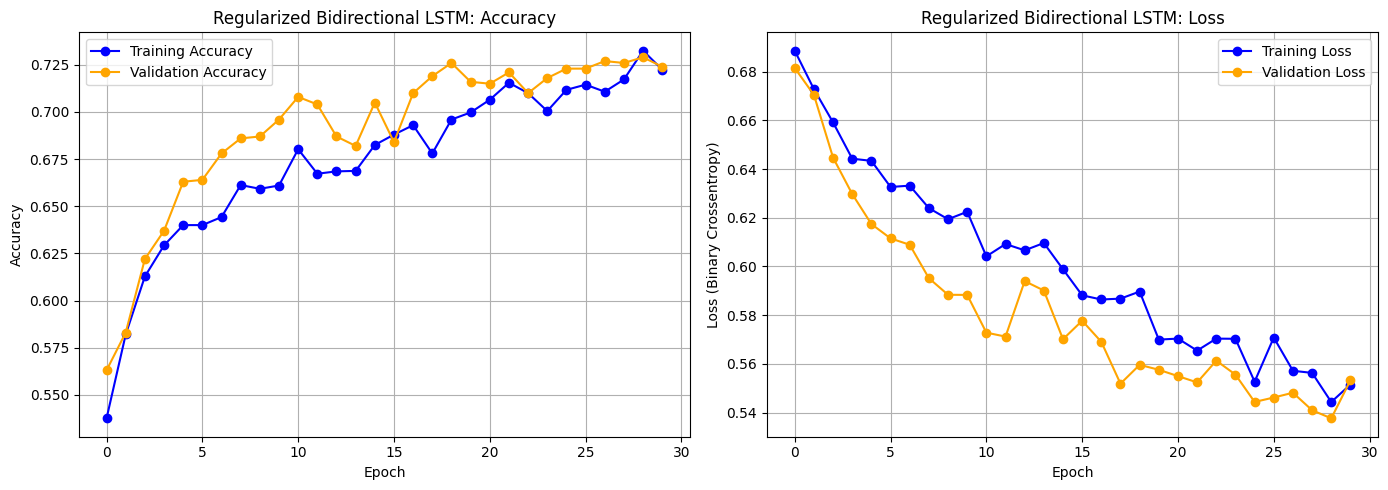

In [5]:

# Train the model (Increased to 30 epochs for regularized learning)
print("Starting Regularized Bidirectional training...")
history_bi = bidirectional_model.fit(
    X,
    Y,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

# Plot Accuracy and Loss over Epochs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_bi.history['accuracy'], label='Training Accuracy', color='blue', marker='o')
ax1.plot(history_bi.history['val_accuracy'], label='Validation Accuracy', color='orange', marker='o')
ax1.set_title('Regularized Bidirectional LSTM: Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history_bi.history['loss'], label='Training Loss', color='blue', marker='o')
ax2.plot(history_bi.history['val_loss'], label='Validation Loss', color='orange', marker='o')
ax2.set_title('Regularized Bidirectional LSTM: Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss (Binary Crossentropy)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


## Conclusion & Next Steps
In this module, we explored how to empower our models with context from both the past and the *future* using Bidirectional LSTMs. By training two separate LSTMs—one reading left-to-right and the other right-to-left—and combining their hidden states, we created a model that fully understands the surrounding context of any word the exact moment it is processed.

While Stacked Bidirectional LSTMs are incredibly powerful, they still process data sequentially. This means they cannot take full advantage of parallel hardware (like GPUs)—the network must finish reading word 1 before it can process word 2. Furthermore, even with a memory cell state, LSTMs still struggle to retain perfect context across massive blocks of text containing thousands of words.

To solve these final weaknesses, the deep learning community moved away from sequential processing entirely and invented the "Attention Mechanism" and the Transformer architecture. We will explore these powerful architectures in a future advanced course!

You are now ready to wrap up your learning journey in the **[Course Conclusion](https://www.kaggle.com/code/arminnorouzig/intermediate-nlp-conclusion)**!
